# GVAE vs DirVAE on DeepLesion — Lung Lesions Only

**Contribution originale** : on isole les lésions pulmonaires (`Coarse_lesion_type == 5`, N=2394) du dataset DeepLesion et on compare le GVAE (VAE gaussien standard) au DirVAE ( Dirichlet) en termes de :
- Qualité de reconstruction (SSIM, MAE)
- Structure de l'espace latent (UMAP)
- Disentanglement visuel

## 0. Installations

In [85]:
!pip install pytorch-msssim umap-learn --quiet

## 1. Imports & Configuration

In [81]:
import os, math, random, time, warnings
import numpy as np
import pandas as pd
from PIL import Image
from time import perf_counter
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import Dataset, DataLoader, random_split
from torch.distributions.dirichlet import Dirichlet
from torchvision.utils import make_grid
from pytorch_msssim import ssim, ms_ssim

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import umap

warnings.filterwarnings('ignore')
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# ── Chemins ─────────────────────────────────────────────────────────────────

IMAGES_DIR = '/kaggle/input/datasets/camescope/deepleasion-genai/deeplesion'   
CSV_PATH   = '/kaggle/input/datasets/kmader/nih-deeplesion-subset/DL_info.csv'  

OUTPUT_DIR = '/kaggle/working/results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Hyperparamètres ──────────────────────────────────────────────────────────
HU_LOWER   = -1000
HU_UPPER   =  400
HU_OFFSET = 32768
IMG_SIZE   =  64
PAD        =  10

BASE         = 32        # feature maps de base
LATENT_SIZE  = 8         # latent_dim = BASE * LATENT_SIZE = 256
BATCH_SIZE   = 64
EPOCHS       = 60
LR           = 1e-4
BETA         = 5.0       # beta-VAE
ALPHA_SSIM   = 0.75      # poids reconstruction vs SSIM
ALPHA_FILL   = 0.99       # prior Dirichlet (concentration)

print(f'Latent dim : {BASE * LATENT_SIZE}')

Device: cpu
Latent dim : 256


## 2. Dataset — lésions pulmonaires uniquement

In [68]:
def _to_subfolder_path(file_name):
    """Normalise File_name vers le format sous-dossier."""
    if '/' in file_name:
        return file_name
    folder, fname = file_name.rsplit('_', 1)
    return folder + '/' + fname


class DeepLesionLung(Dataset):
    """
    Charge uniquement les lésions pulmonaires (Coarse_lesion_type == 5)
    de DL_info.csv, crop sur la bounding box, normalise en HU et resize 64x64.
    """
    HU_OFFSET = 32768

    def __init__(self, df, images_dir, HU_Lower=HU_LOWER, HU_Upper=HU_UPPER,
                 img_size=IMG_SIZE, pad=PAD):
        self.images_dir = images_dir
        self.HU_Lower   = HU_Lower
        self.HU_Upper   = HU_Upper
        self.img_size   = img_size
        self.pad        = pad

        df = df.copy()
        df['_path'] = df['File_name'].apply(_to_subfolder_path)
        mask = df['_path'].apply(
            lambda p: os.path.exists(os.path.join(images_dir, p))
        )
        self.df = df[mask].reset_index(drop=True)
        print(f'  Lésions pulmonaires trouvées sur disque : {len(self.df)}/{len(df)}')

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.images_dir, row['_path'])

        img_array = np.array(Image.open(img_path), dtype=np.float32)
        img_hu    = img_array - self.HU_OFFSET

        bbox  = [float(v) for v in str(row['Bounding_boxes']).split(',')]
        x1, y1, x2, y2 = int(bbox[0]), int(bbox[1]), int(bbox[2]), int(bbox[3])
        h, w  = img_hu.shape
        x1 = max(0, x1 - self.pad);  y1 = max(0, y1 - self.pad)
        x2 = min(w, x2 + self.pad);  y2 = min(h, y2 + self.pad)
        cropped = img_hu[y1:y2, x1:x2]

        cropped = np.clip(cropped, self.HU_Lower, self.HU_Upper)
        cropped = (cropped - self.HU_Lower) / (self.HU_Upper - self.HU_Lower)

        pil_img = Image.fromarray((cropped * 255).astype(np.uint8))
        pil_img = pil_img.resize((self.img_size, self.img_size), Image.BILINEAR)
        final   = np.array(pil_img, dtype=np.float32) / 255.0

        return torch.from_numpy(final).unsqueeze(0)  # (1, 64, 64)


# ── Chargement ───────────────────────────────────────────────────────────────
df_all  = pd.read_csv(CSV_PATH)
df_lung = df_all[df_all['Coarse_lesion_type'] == 5].copy()
print(f'Lésions pulmonaires dans le CSV : {len(df_lung)}')

full_ds = DeepLesionLung(df_lung, IMAGES_DIR)

n_total = len(full_ds)
n_val   = int(0.15 * n_total)
n_test  = int(0.15 * n_total)
n_train = n_total - n_val - n_test

train_ds, val_ds, test_ds = random_split(
    full_ds, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)
print(f'Train: {n_train} | Val: {n_val} | Test: {n_test}')

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

Lésions pulmonaires dans le CSV : 2394
  Lésions pulmonaires trouvées sur disque : 100/2394
Train: 70 | Val: 15 | Test: 15


### Visualisation : exemples de lésions pulmonaires

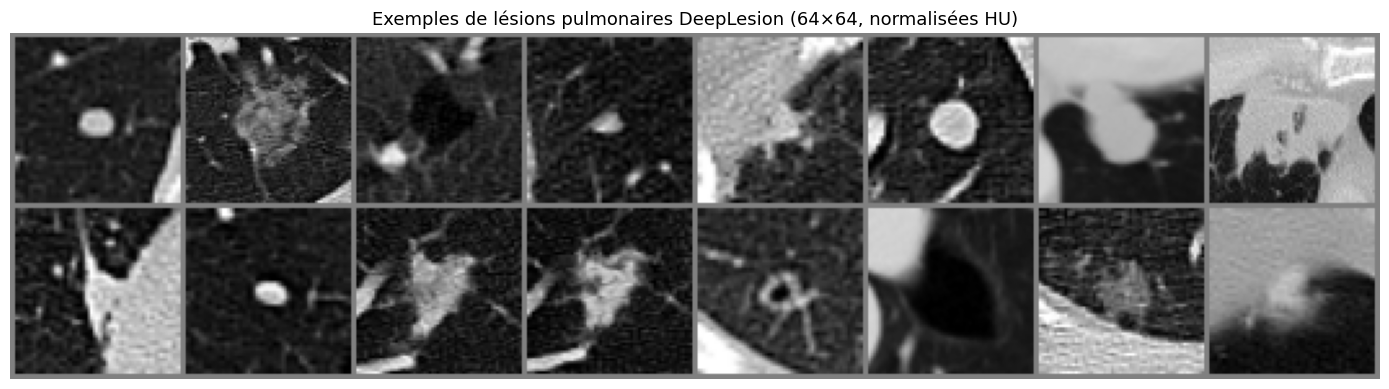

In [69]:
batch = next(iter(train_loader))
grid  = make_grid(batch[:16], nrow=8, padding=2, pad_value=0.5)

plt.figure(figsize=(14, 4))
plt.imshow(grid[0].numpy(), cmap='gray')
plt.axis('off')
plt.title('Exemples de lésions pulmonaires DeepLesion (64×64, normalisées HU)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'lung_samples.png'), dpi=120)
plt.show()

## 3. Architectures

In [71]:
# ── Blocs convolutifs partagés ────────────────────────────────────────────────

class Conv(nn.Module):
    def __init__(self, in_ch, out_ch, k, stride=1, pad=0):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, k, stride, pad, bias=False),
            nn.GELU(),
            nn.BatchNorm2d(out_ch)
        )
    def forward(self, x): return self.conv(x)


class ConvTranspose(nn.Module):
    def __init__(self, in_ch, out_ch, k, stride=1, pad=0):
        super().__init__()
        self.conv = nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, k, stride, pad, bias=False),
            nn.GELU(),
            nn.BatchNorm2d(out_ch)
        )
    def forward(self, x): return self.conv(x)


class ConvUpsampling(nn.Module):
    """Upsampling bilinéaire + Conv (évite les checkerboard artifacts)."""
    def __init__(self, in_ch, out_ch, k, stride=1, pad=0):
        super().__init__()
        self.scale = k
        self.conv  = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, k, stride, pad, bias=False),
            nn.GELU(),
            nn.BatchNorm2d(out_ch)
        )
    def forward(self, x):
        x = F.interpolate(x, scale_factor=self.scale, mode='bilinear', align_corners=False)
        return self.conv(x)


def _build_encoder(base, latent_size):
    """Encodeur partagé entre GVAE et DirVAE."""
    return nn.Sequential(
        Conv(1,      base,   3, stride=1, pad=1),   # 64
        Conv(base,   2*base, 3, stride=1, pad=1),   # 64
        Conv(2*base, 2*base, 3, stride=2, pad=1),   # 32
        Conv(2*base, 2*base, 3, stride=1, pad=1),   # 32
        Conv(2*base, 4*base, 3, stride=2, pad=1),   # 16
        Conv(4*base, 4*base, 3, stride=1, pad=1),   # 16
        Conv(4*base, 4*base, 3, stride=2, pad=1),   # 8
        nn.Conv2d(4*base, 32*base, 8),               # 1
        nn.GELU()
    )


def _build_decoder(base, latent_size):
    """Décodeur partagé entre GVAE et DirVAE."""
    return nn.Sequential(
        nn.Conv2d(latent_size*base, 32*base, 1),
        ConvTranspose(32*base, 4*base, 8),
        Conv(4*base, 4*base, 3, pad=1),
        ConvUpsampling(4*base, 4*base, 4, stride=2, pad=1),
        Conv(4*base, 2*base, 3, pad=1),
        ConvUpsampling(2*base, 2*base, 4, stride=2, pad=1),
        Conv(2*base, base, 3, pad=1),
        ConvUpsampling(base, base, 4, stride=2, pad=1),
        nn.Conv2d(base, 1, 3, padding=1),
        nn.Sigmoid()
    )

In [72]:
# ── GVAE (prior gaussien N(0,1)) ──────────────────────────────────────────────

class GVAE(nn.Module):
    def __init__(self, base=BASE, latent_size=LATENT_SIZE):
        super().__init__()
        self.base         = base
        self.latent_size  = latent_size
        self.encoder      = _build_encoder(base, latent_size)
        self.encoder_mu   = nn.Conv2d(32*base, latent_size*base, 1)
        self.encoder_logv = nn.Conv2d(32*base, latent_size*base, 1)
        self.decoder      = _build_decoder(base, latent_size)

    def encode(self, x):
        h = self.encoder(x)
        return self.encoder_mu(h), self.encoder_logv(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


def param_count(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

gvae = GVAE(BASE, LATENT_SIZE)
print(f'GVAE  — paramètres : {param_count(gvae):,}')

GVAE  — paramètres : 18,613,633


In [84]:
# ── DirVAE (prior Dirichlet) ──────────────────────────────────────────────────
# Ref : Joo et al. (2020), IEEE — reparameterisation trick Dirichlet

class ResampleDir(nn.Module):
    """Module de reparamétrisation Dirichlet."""
    def __init__(self, latent_dim, alpha_fill=ALPHA_FILL):
        super().__init__()
        self.alpha_fill = alpha_fill
        self.latent_dim = latent_dim

    def concentrations_from_logits(self, logits):
        # F.softplus est numériquement stable : log(1 + exp(x)) sans underflow
        # + 1e-6 garantit que toutes les concentrations sont strictement > 0
        return F.softplus(logits) + 1e-6

    def dirichlet_kl(self, logits, eps=1e-10):
        alpha_pred   = self.concentrations_from_logits(logits)          # (B, L)
        alpha_target = torch.full_like(alpha_pred, self.alpha_fill)     # (B, L)
    
        a0_p = alpha_pred.sum(-1, keepdim=True)    # (B, 1)
        a0_t = alpha_target.sum(-1, keepdim=True)  # (B, 1)
    
        # KL(Dir(alpha_pred) || Dir(alpha_target)) — toujours >= 0
        kl = (torch.lgamma(a0_p) - torch.lgamma(a0_t)
              - (torch.lgamma(alpha_pred) - torch.lgamma(alpha_target)).sum(-1, keepdim=True)
              + ((alpha_pred - alpha_target) *
                 (torch.digamma(alpha_pred) - torch.digamma(a0_p))).sum(-1, keepdim=True)
             )
        return kl.mean().clamp(min=0)

    def sample(self, logits):
        alpha_pred = self.concentrations_from_logits(logits)
        return Dirichlet(alpha_pred).rsample()


class DirVAE(nn.Module):
    def __init__(self, base=BASE, latent_size=LATENT_SIZE, alpha_fill=ALPHA_FILL):
        super().__init__()
        self.base        = base
        self.latent_size = latent_size
        self.encoder     = _build_encoder(base, latent_size)
        self.alpha_fc    = nn.Linear(latent_size * base, latent_size * base)
        self.decoder     = _build_decoder(base, latent_size)
        self.resampler   = ResampleDir(latent_size * base, alpha_fill)

    def encode(self, x):
        h = self.encoder(x)                            # (B, 32*base, 1, 1)
        h = h.view(h.size(0), -1)                      # (B, 32*base)
        h = h[:, :self.latent_size * self.base]
        return self.alpha_fc(h)                        # (B, latent_size*base)

    def forward(self, x):
        alpha_logits = self.encode(x)                  # (B, L)
        z = self.resampler.sample(alpha_logits)        # (B, L)
        z = z.view(z.size(0), self.latent_size * self.base, 1, 1)
        recon = self.decoder(z)
        return recon, alpha_logits


dirvae = DirVAE(BASE, LATENT_SIZE)
print(f'DirVAE — paramètres : {param_count(dirvae):,}')

DirVAE — paramètres : 18,154,625


## 4. Fonctions de perte

In [98]:
def kl_annealing(epoch, max_epochs, weight_max=1.0):
    return weight_max * (1 - math.exp(-5 * epoch / max_epochs))


def gvae_loss(recon, x, mu, logvar, epoch, beta=BETA, alpha_ssim=ALPHA_SSIM):
    """
    Loss GVAE = alpha * L1 + (1-alpha) * (1-SSIM) + beta_norm * KLD
    """
    scale = 1.0 / (BATCH_SIZE * BASE)
    ann   = kl_annealing(epoch, EPOCHS)

    kld       = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    l1        = F.l1_loss(recon, x, reduction='sum') * scale
    ssim_loss = 1.0 - ssim(x, recon, data_range=1.0, nonnegative_ssim=True)
    recon_mix = alpha_ssim * l1 + (1 - alpha_ssim) * ssim_loss

    beta_norm = beta * LATENT_SIZE * BASE / (64 * 64)
    total     = recon_mix + beta_norm * kld * ann

    ssim_score = ssim(x, recon, data_range=1.0, nonnegative_ssim=True)
    l1_mean    = F.l1_loss(recon, x)
    kld_mean   = -0.5 * torch.mean(1 + logvar - mu**2 - logvar.exp())
    pure       = l1_mean + kld_mean

    return total, l1_mean, kld_mean, ssim_score, pure


def dirvae_loss(recon, x, alpha_logits, epoch, beta=BETA, alpha_ssim=ALPHA_SSIM):
    """
    Loss DirVAE = alpha * L1 + (1-alpha) * (1-SSIM) + beta_norm * KL_Dirichlet
    """
    ann   = kl_annealing(epoch, EPOCHS)

    l1        = F.l1_loss(recon, x, reduction='mean')
    ssim_loss = 1.0 - ssim(x, recon, data_range=1.0, nonnegative_ssim=True)
    recon_mix = alpha_ssim * l1 + (1 - alpha_ssim) * ssim_loss

    # resampler pour le KL (même alpha_fill que le modèle)
    resampler = dirvae.resampler
    kld       = resampler.dirichlet_kl(alpha_logits)
    kld       = kld.abs()

    beta_norm = beta * LATENT_SIZE * BASE / (64 * 64)
    total     = recon_mix + beta_norm * kld * ann

    ssim_score = ssim(x, recon, data_range=1.0, nonnegative_ssim=True)
    pure       = l1 + kld

    return total, l1, kld, ssim_score, pure

## 5. Boucle d'entraînement

In [76]:
def train_epoch_gvae(model, loader, optimiser, epoch):
    model.train()
    total_loss, total_l1, total_kld, total_ssim = 0, 0, 0, 0
    for x in loader:
        x = x.float().to(device)
        optimiser.zero_grad()
        recon, mu, logvar = model(x)
        loss, l1, kld, ssim_s, pure = gvae_loss(recon, x, mu, logvar, epoch)
        loss.backward()
        optimiser.step()
        total_loss += pure.item()
        total_l1   += l1.item()
        total_kld  += kld.item()
        total_ssim += ssim_s.item()
    n = len(loader)
    return total_loss/n, total_l1/n, total_kld/n, total_ssim/n


def eval_epoch_gvae(model, loader, epoch):
    model.eval()
    total_loss, total_ssim = 0, 0
    with torch.no_grad():
        for x in loader:
            x = x.float().to(device)
            recon, mu, logvar = model(x)
            loss, l1, kld, ssim_s, pure = gvae_loss(recon, x, mu, logvar, epoch)
            total_loss += pure.item()
            total_ssim += ssim_s.item()
    n = len(loader)
    return total_loss/n, total_ssim/n


def train_epoch_dirvae(model, loader, optimiser, epoch):
    model.train()
    total_loss, total_l1, total_kld, total_ssim = 0, 0, 0, 0
    for x in loader:
        x = x.float().to(device)
        optimiser.zero_grad()
        recon, alpha_logits = model(x)
        loss, l1, kld, ssim_s, pure = dirvae_loss(recon, x, alpha_logits, epoch)
        loss.backward()
        optimiser.step()
        total_loss += pure.item()
        total_l1   += l1.item()
        total_kld  += kld.item()
        total_ssim += ssim_s.item()
    n = len(loader)
    return total_loss/n, total_l1/n, total_kld/n, total_ssim/n


def eval_epoch_dirvae(model, loader, epoch):
    model.eval()
    total_loss, total_ssim = 0, 0
    with torch.no_grad():
        for x in loader:
            x = x.float().to(device)
            recon, alpha_logits = model(x)
            loss, l1, kld, ssim_s, pure = dirvae_loss(recon, x, alpha_logits, epoch)
            total_loss += pure.item()
            total_ssim += ssim_s.item()
    n = len(loader)
    return total_loss/n, total_ssim/n


def train_model(model, model_name, train_fn, eval_fn, epochs=EPOCHS, lr=LR):
    model = model.to(device)
    opt   = optim.Adam(model.parameters(), lr=lr)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, 'min', factor=0.5, patience=10, threshold=1e-3)

    history = defaultdict(list)
    best_val = float('inf')
    t0 = perf_counter()

    for epoch in range(1, epochs + 1):
        tr_loss, tr_l1, tr_kld, tr_ssim = train_fn(model, train_loader, opt, epoch)
        va_loss, va_ssim               = eval_fn(model, val_loader, epoch)
        sched.step(tr_loss)

        history['tr_loss'].append(tr_loss)
        history['va_loss'].append(va_loss)
        history['tr_ssim'].append(tr_ssim)
        history['va_ssim'].append(va_ssim)
        history['tr_kld'].append(tr_kld)
        history['tr_l1'].append(tr_l1)

        if va_loss < best_val:
            best_val = va_loss
            torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, f'{model_name}_best.pt'))

        if epoch % 10 == 0 or epoch == 1:
            elapsed = perf_counter() - t0
            print(f'[{model_name}] Epoch {epoch:3d}/{epochs} '
                  f'| TrainLoss {tr_loss:.4f}  ValLoss {va_loss:.4f} '
                  f'| TrainSSIM {tr_ssim:.4f}  ValSSIM {va_ssim:.4f} '
                  f'| {elapsed:.0f}s')

    print(f'[{model_name}] Entraînement terminé en {perf_counter()-t0:.0f}s')
    # Charge le meilleur
    model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, f'{model_name}_best.pt')))
    return model, history

## 6. Entraînement GVAE

In [99]:
gvae = GVAE(BASE, LATENT_SIZE)
gvae, gvae_history = train_model(
    gvae, 'GVAE',
    train_epoch_gvae,
    eval_epoch_gvae,
    epochs=EPOCHS
)

[GVAE] Epoch   1/60 | TrainLoss 0.3744  ValLoss 0.3192 | TrainSSIM 0.0796  ValSSIM 0.1920 | 9s
[GVAE] Epoch  10/60 | TrainLoss 0.7263  ValLoss 0.3181 | TrainSSIM 0.2687  ValSSIM 0.2000 | 93s
[GVAE] Epoch  20/60 | TrainLoss 0.9394  ValLoss 0.3005 | TrainSSIM 0.3906  ValSSIM 0.2454 | 181s
[GVAE] Epoch  30/60 | TrainLoss 0.8478  ValLoss 0.4073 | TrainSSIM 0.3088  ValSSIM 0.2780 | 269s
[GVAE] Epoch  40/60 | TrainLoss 0.8569  ValLoss 0.5316 | TrainSSIM 0.3849  ValSSIM 0.2998 | 357s
[GVAE] Epoch  50/60 | TrainLoss 0.8677  ValLoss 0.5734 | TrainSSIM 0.3855  ValSSIM 0.2953 | 448s
[GVAE] Epoch  60/60 | TrainLoss 0.8618  ValLoss 0.5533 | TrainSSIM 0.4103  ValSSIM 0.3049 | 536s
[GVAE] Entraînement terminé en 536s


## 7. Entraînement DirVAE

In [86]:
dirvae = DirVAE(BASE, LATENT_SIZE)
dirvae, dirvae_history = train_model(
    dirvae, 'DirVAE',
    train_epoch_dirvae,
    eval_epoch_dirvae,
    epochs=EPOCHS
)

[DirVAE] Epoch   1/60 | TrainLoss 18.2391  ValLoss 13.0630 | TrainSSIM 0.0916  ValSSIM 0.1926 | 9s
[DirVAE] Epoch  10/60 | TrainLoss 5.8641  ValLoss 8.8817 | TrainSSIM 0.1674  ValSSIM 0.1888 | 86s
[DirVAE] Epoch  20/60 | TrainLoss 1.8434  ValLoss 3.9804 | TrainSSIM 0.1567  ValSSIM 0.1840 | 179s
[DirVAE] Epoch  30/60 | TrainLoss 0.8958  ValLoss 1.6791 | TrainSSIM 0.1890  ValSSIM 0.1840 | 265s
[DirVAE] Epoch  40/60 | TrainLoss 0.7748  ValLoss 1.6054 | TrainSSIM 0.1673  ValSSIM 0.1858 | 350s
[DirVAE] Epoch  50/60 | TrainLoss 0.6513  ValLoss 1.4761 | TrainSSIM 0.1994  ValSSIM 0.1871 | 435s
[DirVAE] Epoch  60/60 | TrainLoss 0.6119  ValLoss 1.4110 | TrainSSIM 0.1904  ValSSIM 0.1889 | 519s
[DirVAE] Entraînement terminé en 519s


## 8. Comparaison : courbes de loss

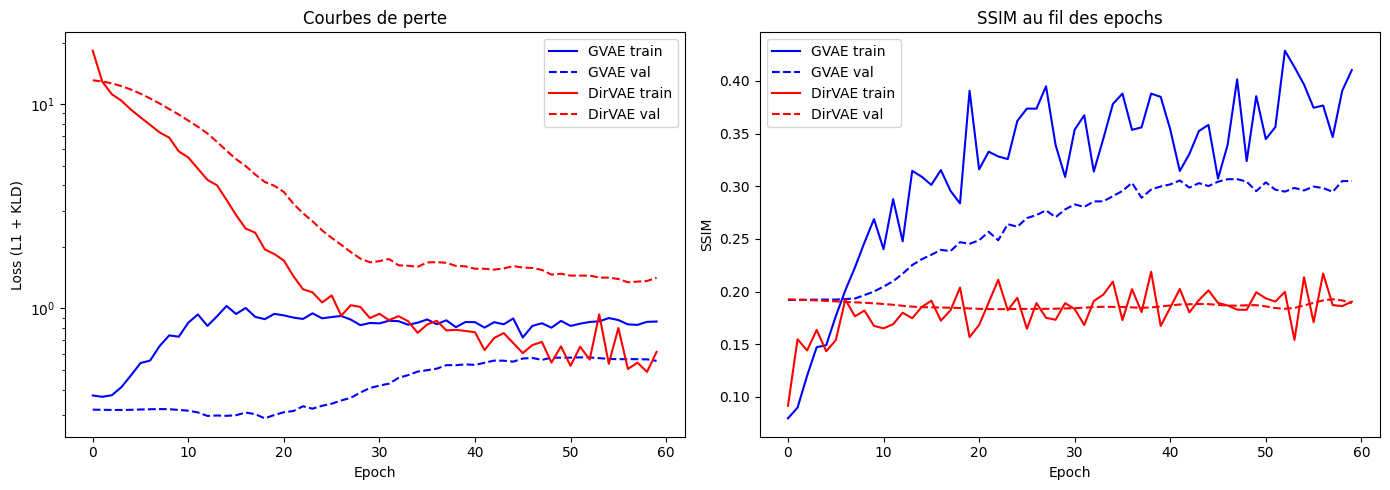

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax = axes[0]
ax.plot(gvae_history['tr_loss'],   'b-',  label='GVAE train')
ax.plot(gvae_history['va_loss'],   'b--', label='GVAE val')
ax.plot(dirvae_history['tr_loss'], 'r-',  label='DirVAE train')
ax.plot(dirvae_history['va_loss'], 'r--', label='DirVAE val')
ax.set_xlabel('Epoch');  ax.set_ylabel('Loss (L1 + KLD)')
ax.set_title('Courbes de perte');  ax.legend();  ax.set_yscale('log')

# SSIM
ax = axes[1]
ax.plot(gvae_history['tr_ssim'],   'b-',  label='GVAE train')
ax.plot(gvae_history['va_ssim'],   'b--', label='GVAE val')
ax.plot(dirvae_history['tr_ssim'], 'r-',  label='DirVAE train')
ax.plot(dirvae_history['va_ssim'], 'r--', label='DirVAE val')
ax.set_xlabel('Epoch');  ax.set_ylabel('SSIM')
ax.set_title('SSIM au fil des epochs');  ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'loss_curves.png'), dpi=120)
plt.show()

## 9. Comparaison : reconstructions sur le test set

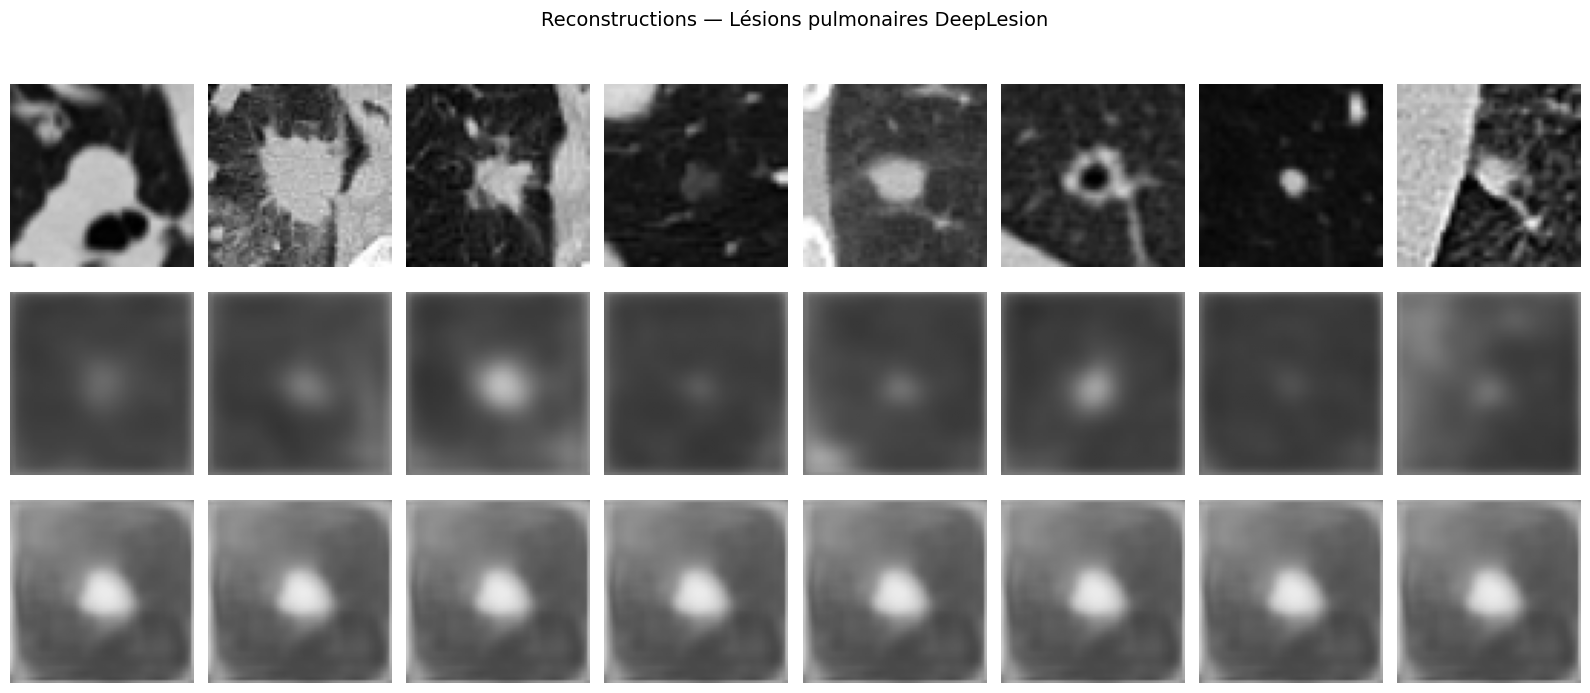

In [101]:
def get_reconstructions(model, loader, model_type='gvae', n=8):
    model.eval()
    originals, recons = [], []
    with torch.no_grad():
        for x in loader:
            x = x.float().to(device)
            if model_type == 'gvae':
                recon, _, _ = model(x)
            else:
                recon, _ = model(x)
            originals.append(x.cpu())
            recons.append(recon.cpu())
            if sum(len(b) for b in originals) >= n:
                break
    return torch.cat(originals)[:n], torch.cat(recons)[:n]


orig_g, recon_g = get_reconstructions(gvae,   test_loader, 'gvae',   n=8)
orig_d, recon_d = get_reconstructions(dirvae, test_loader, 'dirvae', n=8)

fig, axes = plt.subplots(3, 8, figsize=(16, 7))
titles = ['Original', 'GVAE', 'DirVAE']
rows   = [orig_g, recon_g, recon_d]

for row_idx, (row_imgs, title) in enumerate(zip(rows, titles)):
    for col_idx in range(8):
        ax = axes[row_idx, col_idx]
        ax.imshow(row_imgs[col_idx, 0].numpy(), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if col_idx == 0:
            ax.set_ylabel(title, fontsize=12, labelpad=10)

plt.suptitle('Reconstructions — Lésions pulmonaires DeepLesion', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'reconstructions.png'), dpi=120, bbox_inches='tight')
plt.show()

## 10. Métriques quantitatives sur le test set

In [102]:
def compute_test_metrics(model, loader, model_type='gvae'):
    model.eval()
    ssim_list, mae_list, mse_list = [], [], []
    mse_fn = nn.MSELoss(reduction='mean')
    mae_fn = nn.L1Loss(reduction='mean')

    with torch.no_grad():
        for x in loader:
            x = x.float().to(device)
            if model_type == 'gvae':
                recon, _, _ = model(x)
            else:
                recon, _ = model(x)
            ssim_val = ssim(x, recon, data_range=1.0, nonnegative_ssim=True).item()
            mse_val  = mse_fn(x, recon).item()
            mae_val  = mae_fn(x, recon).item()
            ssim_list.append(ssim_val)
            mse_list.append(mse_val)
            mae_list.append(mae_val)

    return {
        'SSIM (↑)': np.mean(ssim_list),
        'MSE  (↓)': np.mean(mse_list),
        'MAE  (↓)': np.mean(mae_list)
    }


metrics_gvae   = compute_test_metrics(gvae,   test_loader, 'gvae')
metrics_dirvae = compute_test_metrics(dirvae, test_loader, 'dirvae')

df_metrics = pd.DataFrame(
    [metrics_gvae, metrics_dirvae],
    index=['GVAE', 'DirVAE']
).round(4)

print('\n=== Métriques sur le test set (lésions pulmonaires) ===\n')
print(df_metrics.to_string())
df_metrics.to_csv(os.path.join(OUTPUT_DIR, 'metrics.csv'))


=== Métriques sur le test set (lésions pulmonaires) ===

        SSIM (↑)  MSE  (↓)  MAE  (↓)
GVAE      0.2944    0.0514    0.1857
DirVAE    0.2482    0.0936    0.2670


## 11. Visualisation de l'espace latent (UMAP)

In [103]:
def extract_latents_gvae(model, loader, max_samples=1000):
    model.eval()
    mus = []
    with torch.no_grad():
        for x in loader:
            x = x.float().to(device)
            mu, _ = model.encode(x)
            mu = mu.squeeze(-1).squeeze(-1)  # (B, L)
            mus.append(mu.cpu().numpy())
            if sum(len(m) for m in mus) >= max_samples:
                break
    return np.concatenate(mus)[:max_samples]


def extract_latents_dirvae(model, loader, max_samples=1000):
    model.eval()
    alphas = []
    with torch.no_grad():
        for x in loader:
            x = x.float().to(device)
            alpha_logits = model.encode(x)   # (B, L)
            alphas.append(alpha_logits.cpu().numpy())
            if sum(len(a) for a in alphas) >= max_samples:
                break
    return np.concatenate(alphas)[:max_samples]


print('Extraction des vecteurs latents...')
# Utilise le full dataset pour avoir assez de points
full_loader = DataLoader(full_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
z_gvae   = extract_latents_gvae(gvae, full_loader, max_samples=min(2000, n_total))
z_dirvae = extract_latents_dirvae(dirvae, full_loader, max_samples=min(2000, n_total))
print(f'GVAE latents : {z_gvae.shape} | DirVAE latents : {z_dirvae.shape}')

Extraction des vecteurs latents...
GVAE latents : (100, 256) | DirVAE latents : (100, 256)


UMAP en cours...


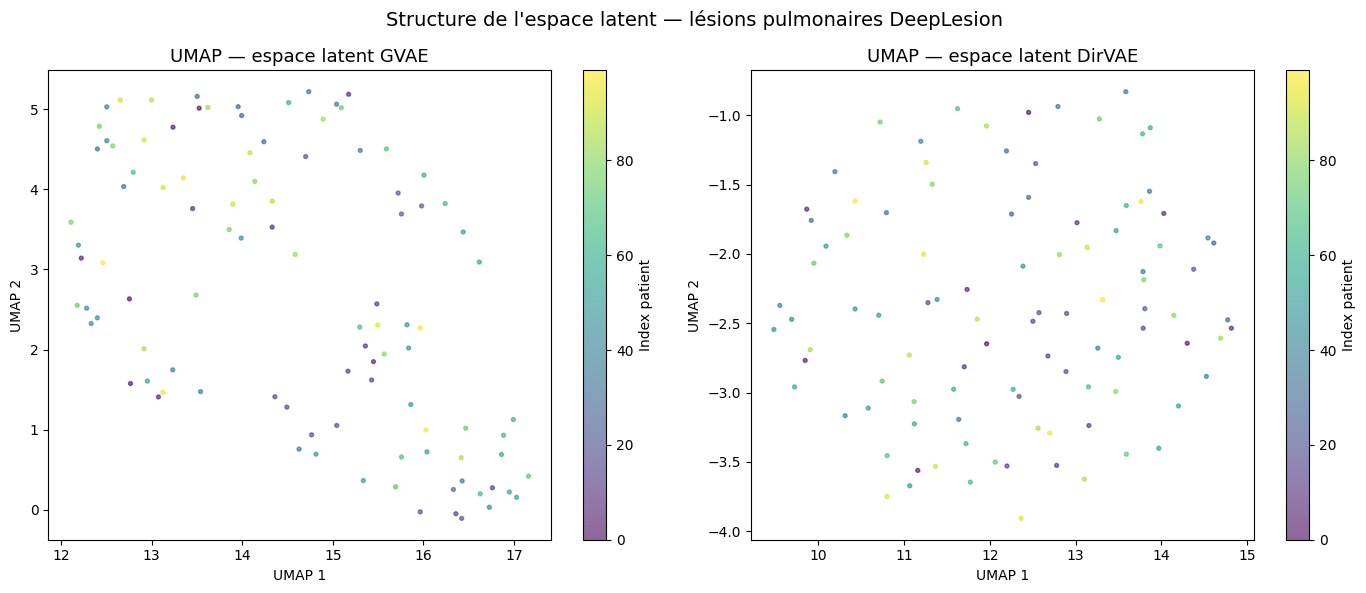

In [104]:
print('UMAP en cours...')
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=20, min_dist=0.1)

umap_gvae   = reducer.fit_transform(z_gvae)
umap_dirvae = reducer.fit_transform(z_dirvae)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, umap_z, name in zip(axes, [umap_gvae, umap_dirvae], ['GVAE', 'DirVAE']):
    sc = ax.scatter(umap_z[:, 0], umap_z[:, 1],
                    s=8, alpha=0.6,
                    c=np.arange(len(umap_z)),   # coloré par ordre de chargement
                    cmap='viridis')
    ax.set_title(f'UMAP — espace latent {name}', fontsize=13)
    ax.set_xlabel('UMAP 1');  ax.set_ylabel('UMAP 2')
    plt.colorbar(sc, ax=ax, label='Index patient')

plt.suptitle('Structure de l\'espace latent — lésions pulmonaires DeepLesion', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'umap_comparison.png'), dpi=120)
plt.show()

## 12. Analyse du disentanglement — traversées latentes

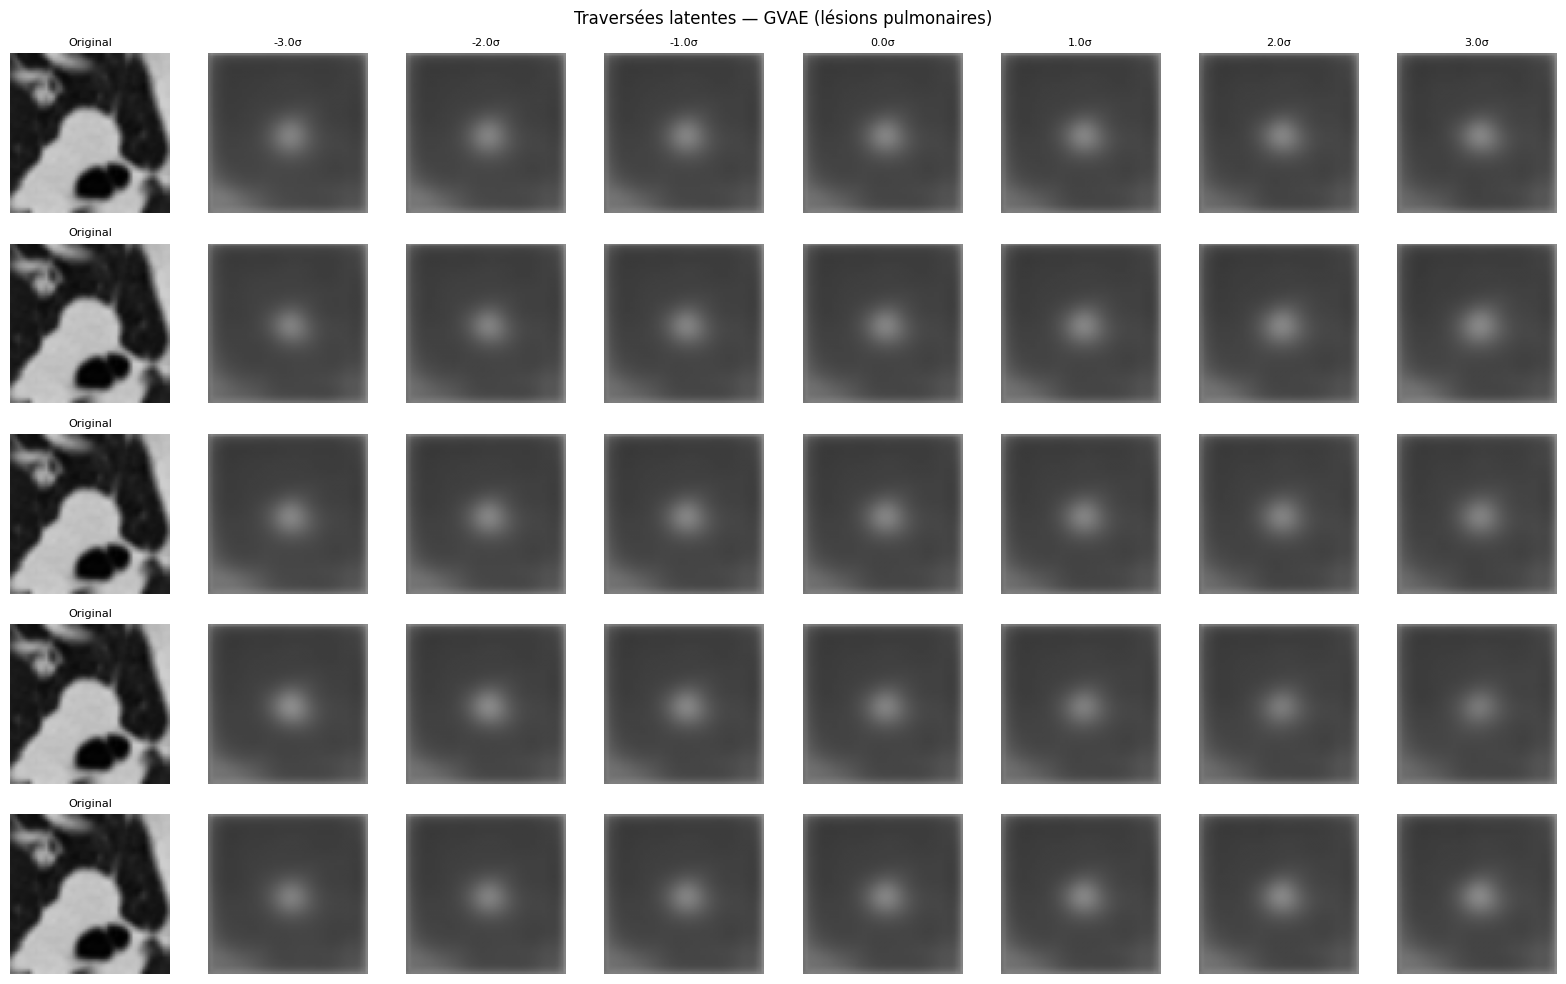

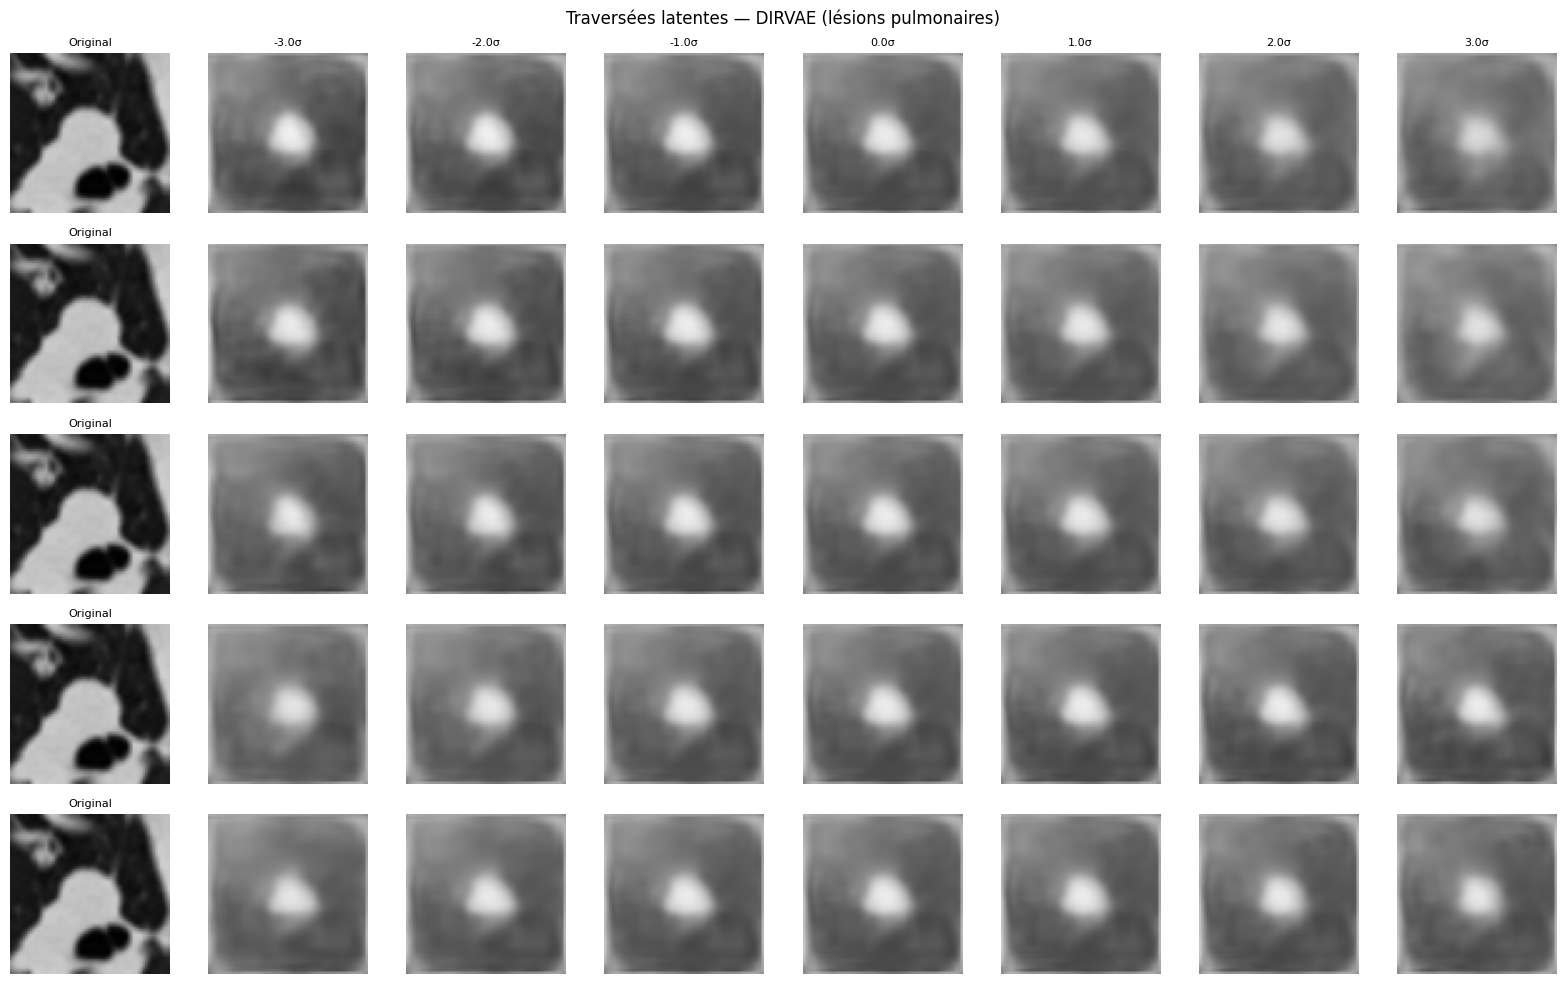

In [105]:
def latent_traversal(model, loader, model_type='gvae', n_dims=5, n_steps=7):
    """
    Pour chaque dimension latente (parmi les n_dims premières), on fait varier
    sa valeur de -3σ à +3σ et on affiche les reconstructions.
    """
    model.eval()
    x_batch = next(iter(loader)).float().to(device)[:1]  # 1 image de référence

    with torch.no_grad():
        if model_type == 'gvae':
            mu, logvar = model.encode(x_batch)
            z_base = mu.clone()  # (1, L, 1, 1)
        else:
            alpha_logits = model.encode(x_batch)
            z_base = model.resampler.sample(alpha_logits)  # (1, L)
            z_base = z_base.view(1, -1, 1, 1)

    L = z_base.shape[1]
    steps = np.linspace(-3, 3, n_steps)

    fig, axes = plt.subplots(n_dims, n_steps + 1, figsize=(2*(n_steps+1), 2*n_dims))

    for d in range(n_dims):
        imgs_row = []
        for v in steps:
            z = z_base.clone()
            z[0, d, 0, 0] = v
            with torch.no_grad():
                recon = model.decode(z) if model_type == 'gvae' else model.decoder(z)
            imgs_row.append(recon[0, 0].cpu().numpy())

        # Affichage original + traversal
        axes[d, 0].imshow(x_batch[0, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
        axes[d, 0].set_title('Original', fontsize=8)
        axes[d, 0].axis('off')

        for j, img in enumerate(imgs_row):
            axes[d, j+1].imshow(img, cmap='gray', vmin=0, vmax=1)
            axes[d, j+1].axis('off')
            if d == 0:
                axes[d, j+1].set_title(f'{steps[j]:.1f}σ', fontsize=8)

        axes[d, 0].set_ylabel(f'Dim {d+1}', fontsize=9, labelpad=5)

    name = model_type.upper()
    plt.suptitle(f'Traversées latentes — {name} (lésions pulmonaires)', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'traversal_{model_type}.png'), dpi=100, bbox_inches='tight')
    plt.show()


latent_traversal(gvae,   test_loader, model_type='gvae',   n_dims=5, n_steps=7)
latent_traversal(dirvae, test_loader, model_type='dirvae', n_dims=5, n_steps=7)

## 13. Distribution des dimensions latentes — GVAE vs DirVAE

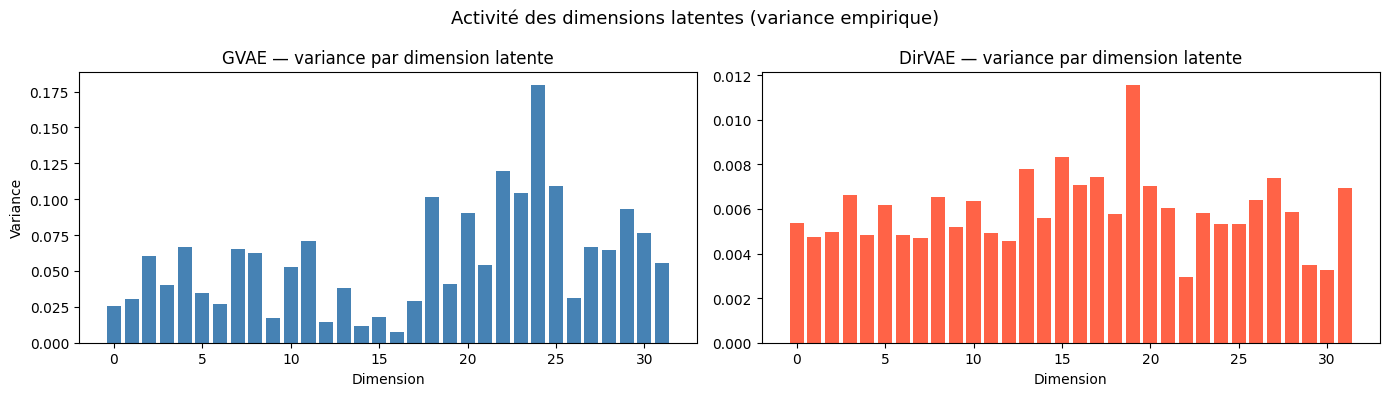

GVAE   — dims actives (var>0.01) : 249/256
DirVAE — dims actives (var>0.01) : 3/256


In [107]:
# Variance de chaque dimension latente → les dims très peu actives sont "mortes" (collapse)
var_gvae   = z_gvae.var(axis=0)    # (L,)
var_dirvae = z_dirvae.var(axis=0)  # (L,)

top_k = 32  # afficher les 32 premières dims

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(top_k), var_gvae[:top_k], color='steelblue')
axes[0].set_title('GVAE — variance par dimension latente'); axes[0].set_xlabel('Dimension'); axes[0].set_ylabel('Variance')

axes[1].bar(range(top_k), var_dirvae[:top_k], color='tomato')
axes[1].set_title('DirVAE — variance par dimension latente'); axes[1].set_xlabel('Dimension')

plt.suptitle('Activité des dimensions latentes (variance empirique)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'latent_variance.png'), dpi=120)
plt.show()

print(f'GVAE   — dims actives (var>0.01) : {(var_gvae > 0.01).sum()}/{len(var_gvae)}')
print(f'DirVAE — dims actives (var>0.01) : {(var_dirvae > 0.01).sum()}/{len(var_dirvae)}')

## 14. Générations synthétiques

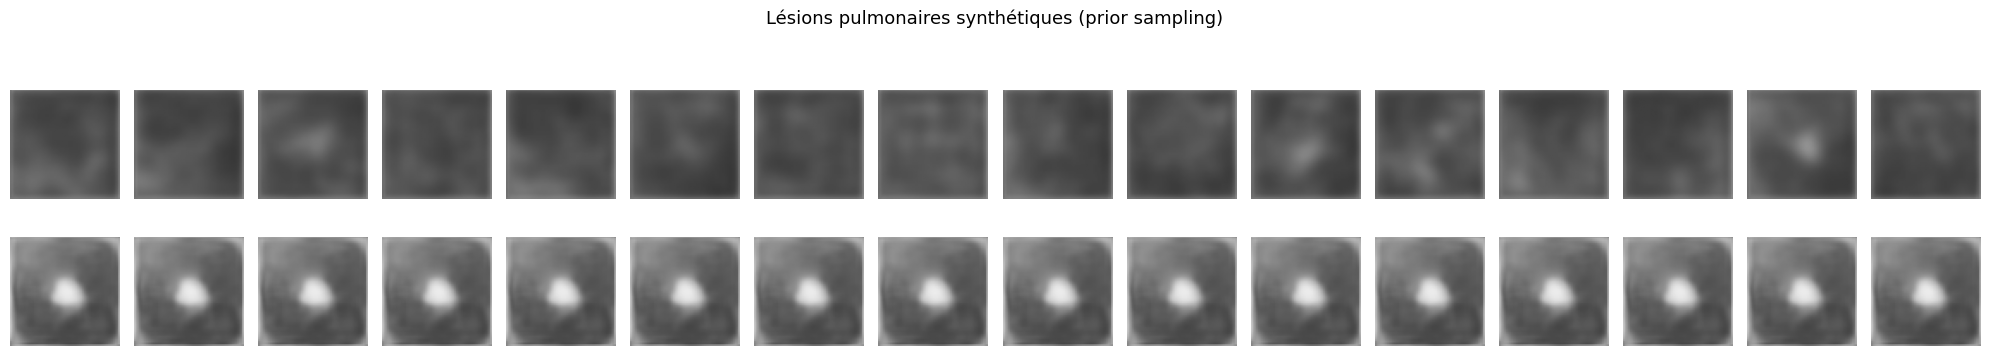

In [108]:
def generate_samples(model, model_type='gvae', n=16):
    model.eval()
    L = BASE * LATENT_SIZE
    with torch.no_grad():
        if model_type == 'gvae':
            z = torch.randn(n, L, 1, 1).to(device)
            imgs = model.decode(z)
        else:
            # Échantillon depuis le prior Dirichlet
            alpha_prior = torch.full((n, L), ALPHA_FILL).to(device)
            z = Dirichlet(alpha_prior).sample().view(n, L, 1, 1)
            imgs = model.decoder(z)
    return imgs.cpu()


samples_g = generate_samples(gvae,   'gvae',   n=16)
samples_d = generate_samples(dirvae, 'dirvae', n=16)

fig, axes = plt.subplots(2, 16, figsize=(20, 4))
for i in range(16):
    axes[0, i].imshow(samples_g[i, 0].numpy(), cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    axes[1, i].imshow(samples_d[i, 0].numpy(), cmap='gray', vmin=0, vmax=1)
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('GVAE',   fontsize=11, labelpad=10)
axes[1, 0].set_ylabel('DirVAE', fontsize=11, labelpad=10)
plt.suptitle('Lésions pulmonaires synthétiques (prior sampling)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'synthetic_samples.png'), dpi=120, bbox_inches='tight')
plt.show()

## 15. Résumé final

In [109]:
print('=' * 60)
print('  RÉSUMÉ — GVAE vs DirVAE sur lésions pulmonaires DeepLesion')
print('=' * 60)
print(f'  Dataset     : {n_total} lésions (Coarse_lesion_type == 5)')
print(f'  Train/Val/Test : {n_train}/{n_val}/{n_test}')
print(f'  Latent dim  : {BASE * LATENT_SIZE}')
print(f'  Epochs      : {EPOCHS}')
print()
print(df_metrics.to_string())
print()
print(f'  GVAE   dims actives : {(var_gvae > 0.01).sum()}/{len(var_gvae)}')
print(f'  DirVAE dims actives : {(var_dirvae > 0.01).sum()}/{len(var_dirvae)}')
print()
print(f'  Fichiers sauvegardés dans : {OUTPUT_DIR}')
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f'    {f}')

  RÉSUMÉ — GVAE vs DirVAE sur lésions pulmonaires DeepLesion
  Dataset     : 100 lésions (Coarse_lesion_type == 5)
  Train/Val/Test : 70/15/15
  Latent dim  : 256
  Epochs      : 60

        SSIM (↑)  MSE  (↓)  MAE  (↓)
GVAE      0.2944    0.0514    0.1857
DirVAE    0.2482    0.0936    0.2670

  GVAE   dims actives : 249/256
  DirVAE dims actives : 3/256

  Fichiers sauvegardés dans : /kaggle/working/results
    DirVAE_best.pt
    GVAE_best.pt
    latent_variance.png
    loss_curves.png
    lung_samples.png
    metrics.csv
    reconstructions.png
    synthetic_samples.png
    traversal_dirvae.png
    traversal_gvae.png
    umap_comparison.png
